In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot  as plt
import os
import datetime as dt

In [3]:
print(os.getcwd())

c:\Users\anaco\OneDrive\Documentos\GitHub\EDA_ClientesAmazon\src\notebooks


In [4]:

#df = pd.read_csv("./src/data/Amazon Customer Behavior Survey.csv")
df = pd.read_csv("../data/Amazon Customer Behavior Survey.csv")
df

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Saveforlater_Frequency,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas
0,2023/06/04 1:28:19 PM GMT+5:30,23,Female,Few times a month,Beauty and Personal Care,Yes,Few times a week,Keyword,Multiple pages,1,...,Sometimes,Yes,Occasionally,Yes,2,Yes,1,1,Competitive prices,Reducing packaging waste
1,2023/06/04 2:30:44 PM GMT+5:30,23,Female,Once a month,Clothing and Fashion,Yes,Few times a month,Keyword,Multiple pages,1,...,Rarely,No,Heavily,Yes,2,Sometimes,3,2,Wide product selection,Reducing packaging waste
2,2023/06/04 5:04:56 PM GMT+5:30,24,Prefer not to say,Few times a month,Groceries and Gourmet Food;Clothing and Fashion,No,Few times a month,Keyword,Multiple pages,2,...,Rarely,No,Occasionally,No,4,No,3,3,Competitive prices,Product quality and accuracy
3,2023/06/04 5:13:00 PM GMT+5:30,24,Female,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,Keyword,First page,5,...,Sometimes,Yes,Heavily,Yes,3,Sometimes,3,4,Competitive prices,Product quality and accuracy
4,2023/06/04 5:28:06 PM GMT+5:30,22,Female,Less than once a month,Beauty and Personal Care;Clothing and Fashion,Yes,Few times a month,Filter,Multiple pages,1,...,Rarely,No,Heavily,Yes,4,Yes,2,2,Competitive prices,Product quality and accuracy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
597,2023/06/12 4:02:02 PM GMT+5:30,23,Female,Once a week,Beauty and Personal Care,Sometimes,Few times a week,categories,Multiple pages,4,...,Sometimes,Yes,Moderately,Sometimes,3,Sometimes,3,4,Competitive prices,Customer service responsiveness
598,2023/06/12 4:02:53 PM GMT+5:30,23,Female,Once a week,Clothing and Fashion,Sometimes,Few times a week,Filter,Multiple pages,3,...,Sometimes,Yes,Heavily,Sometimes,3,Sometimes,3,3,Product recommendations,Reducing packaging waste
599,2023/06/12 4:03:59 PM GMT+5:30,23,Female,Once a month,Beauty and Personal Care,Sometimes,Few times a week,categories,Multiple pages,3,...,Sometimes,Yes,Occasionally,Sometimes,3,Sometimes,2,3,Wide product selection,Product quality and accuracy
600,2023/06/12 9:57:20 PM GMT+5:30,23,Female,Few times a month,Beauty and Personal Care;Clothing and Fashion;...,Yes,Few times a month,Keyword,Multiple pages,1,...,Sometimes,No,Heavily,Yes,2,Yes,2,2,Wide product selection,Product quality and accuracy


In [5]:
# eliminar missing values (solo 2 NA en columna 7)
df.info()

df = df.dropna();

<class 'pandas.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 23 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   Timestamp                               602 non-null    str  
 1   age                                     602 non-null    int64
 2   Gender                                  602 non-null    str  
 3   Purchase_Frequency                      602 non-null    str  
 4   Purchase_Categories                     602 non-null    str  
 5   Personalized_Recommendation_Frequency   602 non-null    str  
 6   Browsing_Frequency                      602 non-null    str  
 7   Product_Search_Method                   600 non-null    str  
 8   Search_Result_Exploration               602 non-null    str  
 9   Customer_Reviews_Importance             602 non-null    int64
 10  Add_to_Cart_Browsing                    602 non-null    str  
 11  Cart_Completion_Frequency     

In [6]:
# limpiar nombres de columnas
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("/", "_")
)

df["timestamp"] = pd.to_datetime(df["timestamp"])
df["age"] = pd.to_numeric(df["age"], errors="coerce")


C:\Users\anaco\AppData\Local\Temp\ipykernel_17976\2782429488.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(df["timestamp"])


In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 600 entries, 0 to 601
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype                    
---  ------                                 --------------  -----                    
 0   timestamp                              600 non-null    datetime64[us, UTC-05:30]
 1   age                                    600 non-null    int64                    
 2   gender                                 600 non-null    str                      
 3   purchase_frequency                     600 non-null    str                      
 4   purchase_categories                    600 non-null    str                      
 5   personalized_recommendation_frequency  600 non-null    str                      
 6   browsing_frequency                     600 non-null    str                      
 7   product_search_method                  600 non-null    str                      
 8   search_result_exploration              600 non

In [8]:
df

,timestamp,age,gender,purchase_frequency,purchase_categories,personalized_recommendation_frequency,browsing_frequency,product_search_method,search_result_exploration,customer_reviews_importance,...,saveforlater_frequency,review_left,review_reliability,review_helpfulness,personalized_recommendation_frequency,recommendation_helpfulness,rating_accuracy,shopping_satisfaction,service_appreciation,improvement_areas
0,2023-06-04 13:28:19-05:30,23,Female,Few times a month,Beauty and Personal Care,Yes,Few times a week,Keyword,Multiple pages,1,...,Sometimes,Yes,Occasionally,Yes,2,Yes,1,1,Competitive prices,Reducing packaging waste
1,2023-06-04 14:30:44-05:30,23,Female,Once a month,Clothing and Fashion,Yes,Few times a month,Keyword,Multiple pages,1,...,Rarely,No,Heavily,Yes,2,Sometimes,3,2,Wide product selection,Reducing packaging waste
2,2023-06-04 17:04:56-05:30,24,Prefer not to say,Few times a month,Groceries and Gourmet Food;Clothing and Fashion,No,Few times a month,Keyword,Multiple pages,2,...,Rarely,No,Occasionally,No,4,No,3,3,Competitive prices,Product quality and accuracy
3,2023-06-04 17:13:00-05:30,24,Female,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,Keyword,First page,5,...,Sometimes,Yes,Heavily,Yes,3,Sometimes,3,4,Competitive prices,Product quality and accuracy
4,2023-06-04 17:28:06-05:30,22,Female,Less than once a month,Beauty and Personal Care;Clothing and Fashion,Yes,Few times a month,Filter,Multiple pages,1,...,Rarely,No,Heavily,Yes,4,Yes,2,2,Competitive prices,Product quality and accuracy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
597,2023-06-12 16:02:02-05:30,23,Female,Once a week,Beauty and Personal Care,Sometimes,Few times a week,categories,Multiple pages,4,...,Sometimes,Yes,Moderately,Sometimes,3,Sometimes,3,4,Competitive prices,Customer service responsiveness
598,2023-06-12 16:02:53-05:30,23,Female,Once a week,Clothing and Fashion,Sometimes,Few times a week,Filter,Multiple pages,3,...,Sometimes,Yes,Heavily,Sometimes,3,Sometimes,3,3,Product recommendations,Reducing packaging waste
599,2023-06-12 16:03:59-05:30,23,Female,Once a month,Beauty and Personal Care,Sometimes,Few times a week,categories,Multiple pages,3,...,Sometimes,Yes,Occasionally,Sometimes,3,Sometimes,2,3,Wide product selection,Product quality and accuracy
600,2023-06-12 21:57:20-05:30,23,Female,Few times a month,Beauty and Personal Care;Clothing and Fashion;...,Yes,Few times a month,Keyword,Multiple pages,1,...,Sometimes,No,Heavily,Yes,2,Yes,2,2,Wide product selection,Product quality and accuracy


In [9]:
# ¿Hay nombres de columnas duplicados?
dup_counts = df.columns.value_counts()
print(dup_counts[dup_counts > 1])

personalized_recommendation_frequency    2
Name: count, dtype: int64


In [10]:
# extraer categorias principales
df["purchase_categories_list"] = (
    df["purchase_categories"]
      .str.split(";")
)

df["buys_beauty"] = df["purchase_categories"].str.contains("Beauty and Personal Care", na=False)
df["buys_fashion"] = df["purchase_categories"].str.contains("Clothing and Fashion", na=False)

In [11]:
df["personalized_recommendation_frequency"] = (
    df["personalized_recommendation_frequency"]
      .astype("category")  # o "string"
)

# reconstruir listas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

C:\Users\anaco\AppData\Local\Temp\ipykernel_17976\2275637314.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


In [12]:
num_cols

['age',
 'customer_reviews_importance',
 'rating_accuracy',
 'shopping_satisfaction']

In [13]:
cat_cols

['gender',
 'purchase_frequency',
 'purchase_categories',
 'personalized_recommendation_frequency',
 'browsing_frequency',
 'product_search_method',
 'search_result_exploration',
 'add_to_cart_browsing',
 'cart_completion_frequency',
 'cart_abandonment_factors',
 'saveforlater_frequency',
 'review_left',
 'review_reliability',
 'review_helpfulness',
 'personalized_recommendation_frequency',
 'recommendation_helpfulness',
 'service_appreciation',
 'improvement_areas',
 'purchase_categories_list']

In [14]:
# Ver qué columnas de cat_cols tienen valores tipo list u otros no hashables
problem_cols = []

for col in cat_cols:
    # sample pequeño para no recorrer todo si el dataset es grande
    sample = df[col].dropna().head(100)
    if sample.apply(lambda x: isinstance(x, (list, dict, set))).any():
        problem_cols.append(col)

problem_cols

['purchase_categories_list']

In [15]:
#columnas de cat_cols tienen valores tipo list u otros no hashables

df["purchase_categories_list"] = df["purchase_categories_list"].apply(
     lambda x: ",".join(map(str, x)) if isinstance(x, list) else x
 )

In [16]:
# Cardinalidad de columnas categóricas
cardinality = df[cat_cols].nunique().sort_values(ascending=False)
cardinality

purchase_categories                      29
purchase_categories_list                 29
improvement_areas                        18
service_appreciation                      9
personalized_recommendation_frequency     5
review_reliability                        5
cart_completion_frequency                 5
purchase_frequency                        5
saveforlater_frequency                    5
personalized_recommendation_frequency     5
gender                                    4
product_search_method                     4
browsing_frequency                        4
cart_abandonment_factors                  4
personalized_recommendation_frequency     3
add_to_cart_browsing                      3
review_helpfulness                        3
personalized_recommendation_frequency     3
recommendation_helpfulness                3
review_left                               2
search_result_exploration                 2
dtype: int64

# 2 Analisis univariante de variables numericas

In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 600 entries, 0 to 601
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype                    
---  ------                                 --------------  -----                    
 0   timestamp                              600 non-null    datetime64[us, UTC-05:30]
 1   age                                    600 non-null    int64                    
 2   gender                                 600 non-null    str                      
 3   purchase_frequency                     600 non-null    str                      
 4   purchase_categories                    600 non-null    str                      
 5   personalized_recommendation_frequency  600 non-null    category                 
 6   browsing_frequency                     600 non-null    str                      
 7   product_search_method                  600 non-null    str                      
 8   search_result_exploration              600 non

In [18]:
num_cols

['age',
 'customer_reviews_importance',
 'rating_accuracy',
 'shopping_satisfaction']

In [19]:
# 2.1 Resumen estadístico de numéricas
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,600.0,30.780000,10.180914,3.0,23.0,26.0,36.0,67.0
customer_reviews_importance,600.0,2.481667,1.185470,1.0,1.0,3.0,3.0,5.0
rating_accuracy,600.0,2.671667,0.901046,1.0,2.0,3.0,3.0,5.0
shopping_satisfaction,600.0,2.463333,1.013427,1.0,2.0,2.0,3.0,5.0


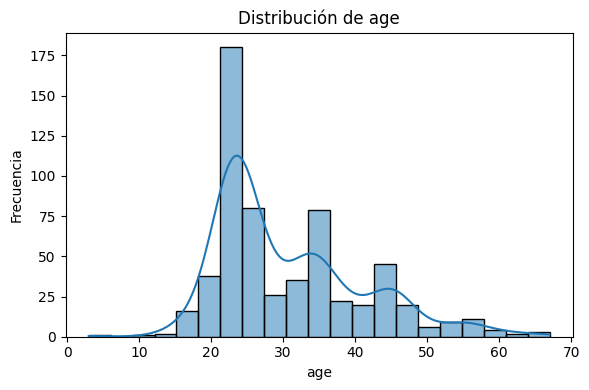

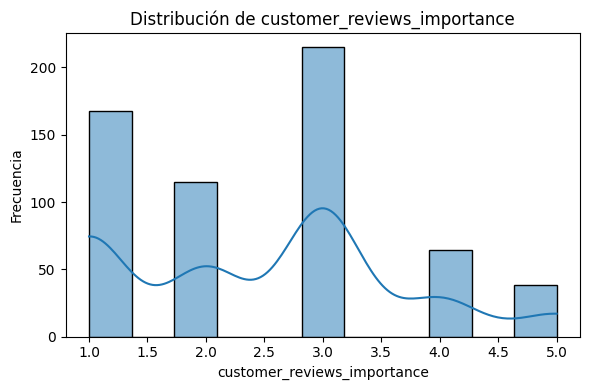

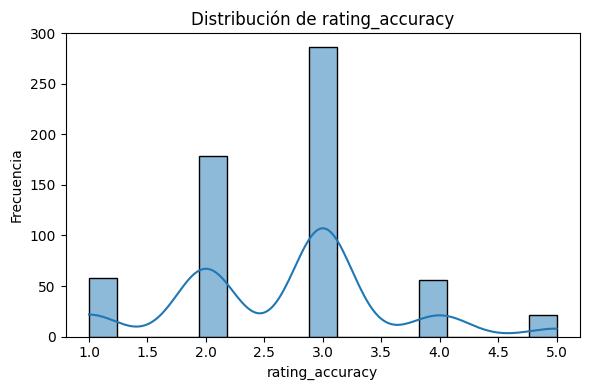

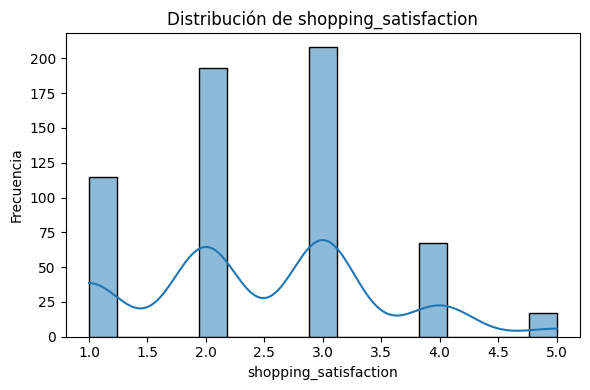

In [20]:
# 2.2 Histogramas + KDE para cada variable numérica

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

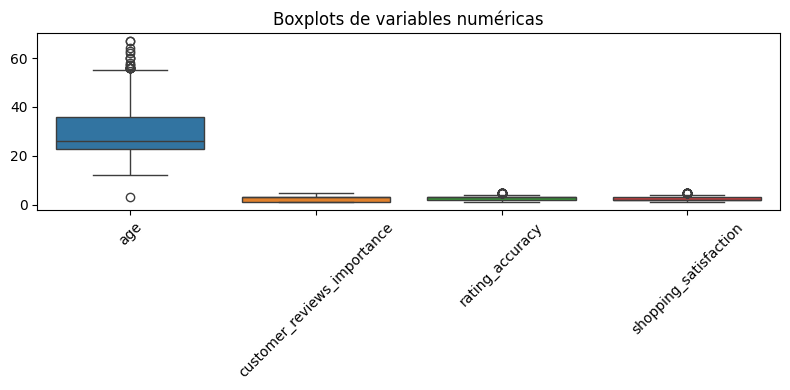

In [21]:
# 2.3 Boxplots para inspección rápida de outliers
plt.figure(figsize=(8, 4))
sns.boxplot(data=df[num_cols])
plt.title("Boxplots de variables numéricas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* Aparentemente no hay mucha asimetria en las distribuciones numericas, unicamente age presenta outliers extremos. 

    - tiene sentido extraer como sub age esos outliers ya que proporcionan informacion del consumo a partir de los 60
* Distribucion

    - Age tiene distribucion sesgada a la derecha (moda)
    - Customer_reviews_importance tiene distribucion bimodal ??
    - Rating accuracy y shopping_satifaction distribucion normal
* Varianza

    - customer_reviews_importance, Rating accuracy y shopping satisfaction tienen bajo std (poca variabilidad)
    - age tiene alta variabilidad


# 3. Análisis univariante de variables categóricas

#### 
Para cada variable categórica se analiza:
- Distribución de frecuencias absolutas.
- Distribución de frecuencias relativas.
- Visualización con gráficos de barras.

Para evitar gráficos inmanejables, limitamos a las `top_n` categorías más frecuentes cuando la cardinalidad es alta.

In [22]:
def categorical_univariate_report(df, col, top_n=10, plot=True):
    vc = df[col].value_counts(dropna=False)
    perc = (vc / len(df)).round(3)
    
    summary = pd.DataFrame({
        "count": vc,
        "fraction": perc
    })
    
    print(f"\n=== {col} ===")
    display(summary.head(top_n))
    
    if plot:
        plt.figure(figsize=(8, 4))
        order = vc.head(top_n).index
        sns.countplot(
            data=df,
            y=col,
            order=order
        )
        plt.title(f"Distribución de {col} (top {top_n})")
        plt.xlabel("Frecuencia")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()



Procesando: gender

=== gender ===


,count,fraction
gender,,
Female,350,0.583
Male,142,0.237
Prefer not to say,89,0.148
Others,19,0.032


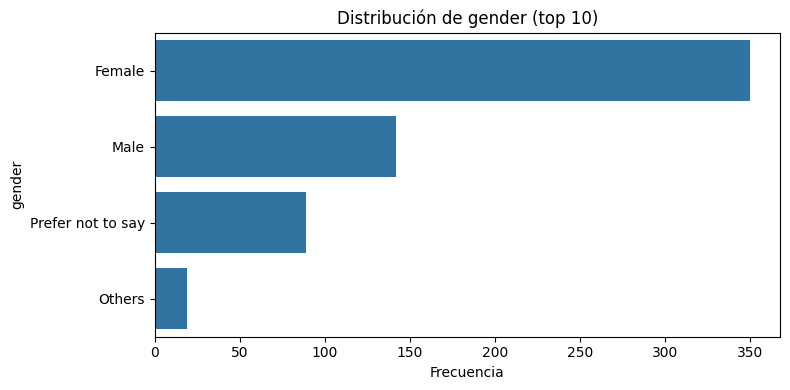


Procesando: purchase_frequency

=== purchase_frequency ===


,count,fraction
purchase_frequency,,
Few times a month,202,0.337
Less than once a month,124,0.207
Once a week,112,0.187
Once a month,106,0.177
Multiple times a week,56,0.093


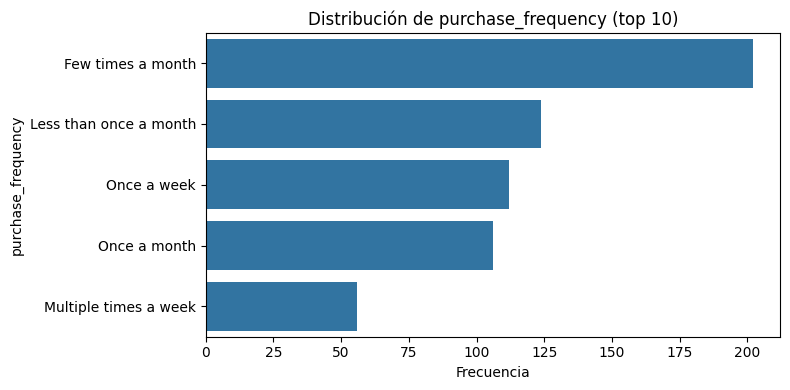


Procesando: purchase_categories

=== purchase_categories ===


,count,fraction
purchase_categories,,
Beauty and Personal Care,106,0.177
Clothing and Fashion,105,0.175
others,48,0.080
Beauty and Personal Care;Clothing and Fashion,46,0.077
Beauty and Personal Care;Clothing and Fashion;Home and Kitchen,42,0.070
Groceries and Gourmet Food;Beauty and Personal Care;Clothing and Fashion;Home and Kitchen;others,32,0.053
Clothing and Fashion;Home and Kitchen,27,0.045
Home and Kitchen,24,0.040
Beauty and Personal Care;Home and Kitchen,21,0.035


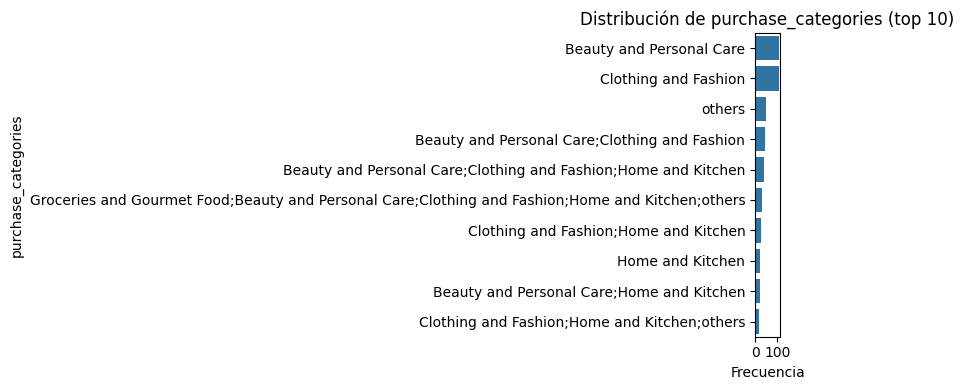


Procesando: personalized_recommendation_frequency
[ERROR] en personalized_recommendation_frequency: Grouper for 'personalized_recommendation_frequency' not 1-dimensional

Procesando: browsing_frequency

=== browsing_frequency ===


,count,fraction
browsing_frequency,,
Few times a week,248,0.413
Few times a month,199,0.332
Rarely,77,0.128
Multiple times a day,76,0.127


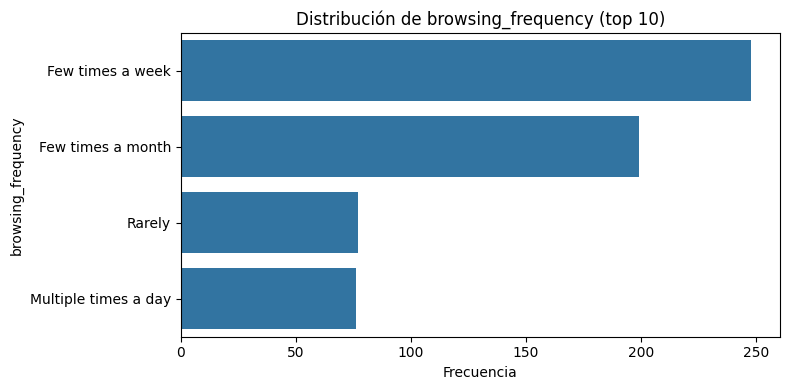


Procesando: product_search_method

=== product_search_method ===


,count,fraction
product_search_method,,
categories,223,0.372
Keyword,214,0.357
Filter,127,0.212
others,36,0.060


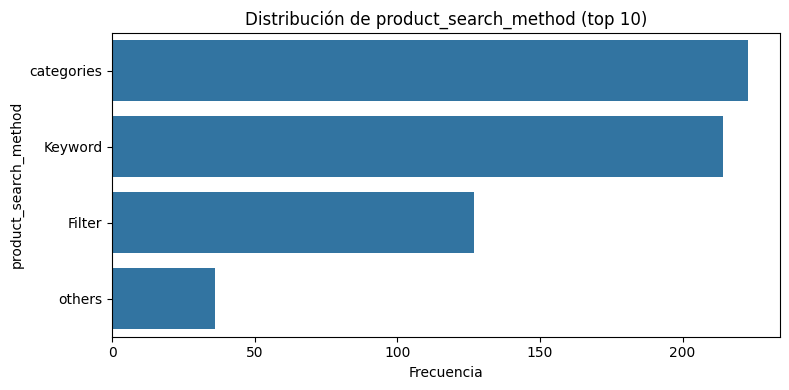


Procesando: search_result_exploration

=== search_result_exploration ===


,count,fraction
search_result_exploration,,
Multiple pages,440,0.733
First page,160,0.267


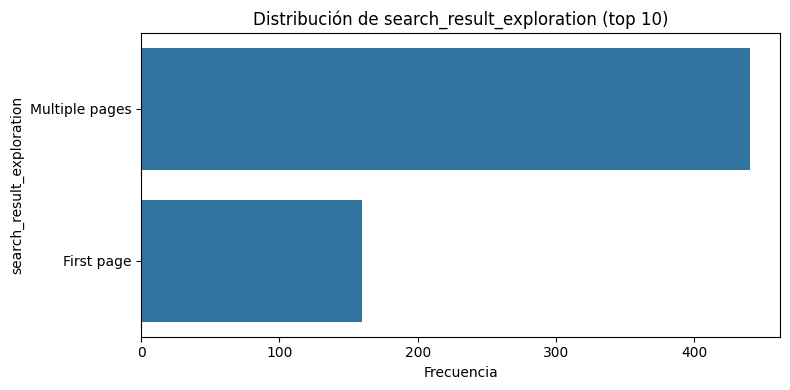


Procesando: add_to_cart_browsing

=== add_to_cart_browsing ===


,count,fraction
add_to_cart_browsing,,
Maybe,247,0.412
Yes,215,0.358
No,138,0.230


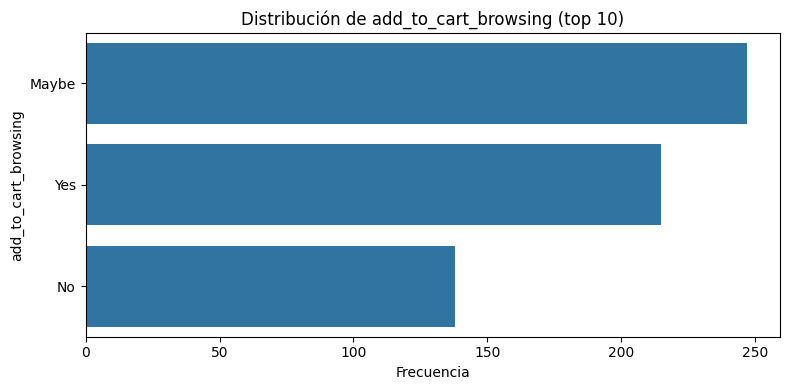


Procesando: cart_completion_frequency

=== cart_completion_frequency ===


,count,fraction
cart_completion_frequency,,
Sometimes,303,0.505
Often,158,0.263
Rarely,72,0.120
Always,46,0.077
Never,21,0.035


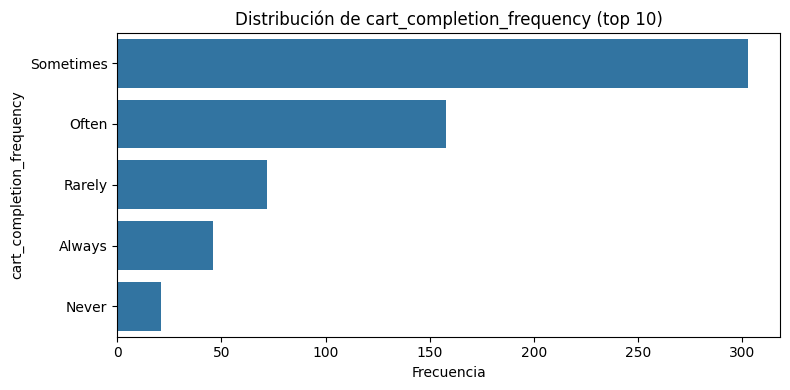


Procesando: cart_abandonment_factors

=== cart_abandonment_factors ===


,count,fraction
cart_abandonment_factors,,
Found a better price elsewhere,254,0.423
Changed my mind or no longer need the item,240,0.400
High shipping costs,70,0.117
others,36,0.060


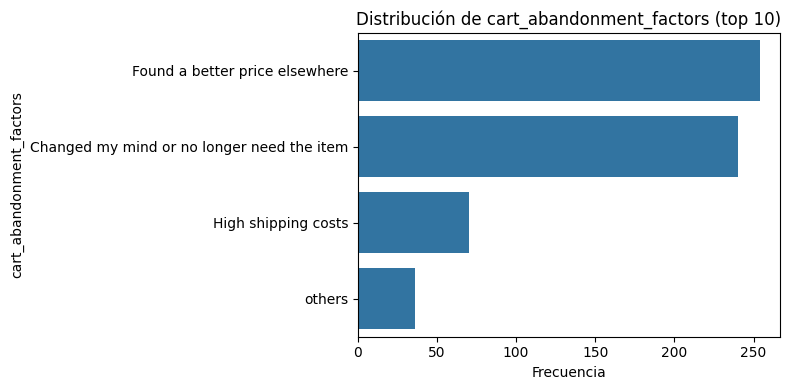


Procesando: saveforlater_frequency

=== saveforlater_frequency ===


,count,fraction
saveforlater_frequency,,
Sometimes,251,0.418
Often,154,0.257
Rarely,82,0.137
Never,59,0.098
Always,54,0.090


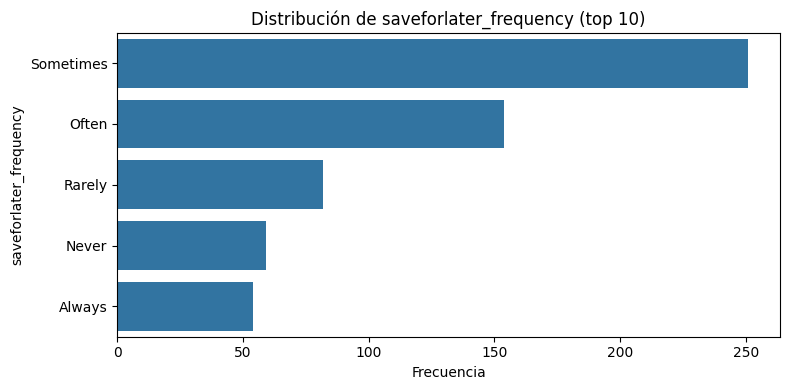


Procesando: review_left

=== review_left ===


,count,fraction
review_left,,
Yes,310,0.517
No,290,0.483


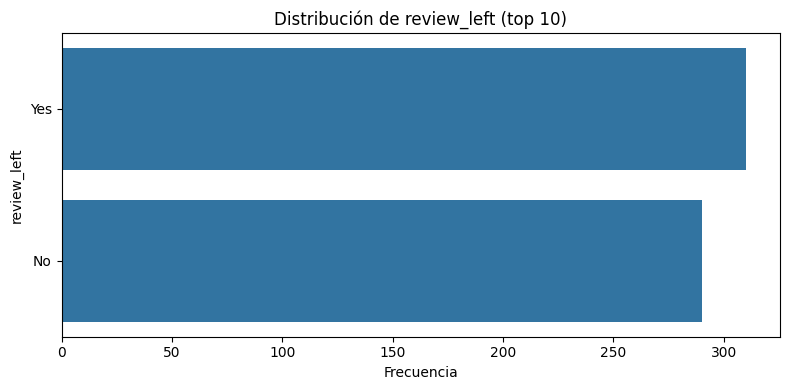


Procesando: review_reliability

=== review_reliability ===


,count,fraction
review_reliability,,
Moderately,197,0.328
Occasionally,190,0.317
Heavily,149,0.248
Rarely,41,0.068
Never,23,0.038


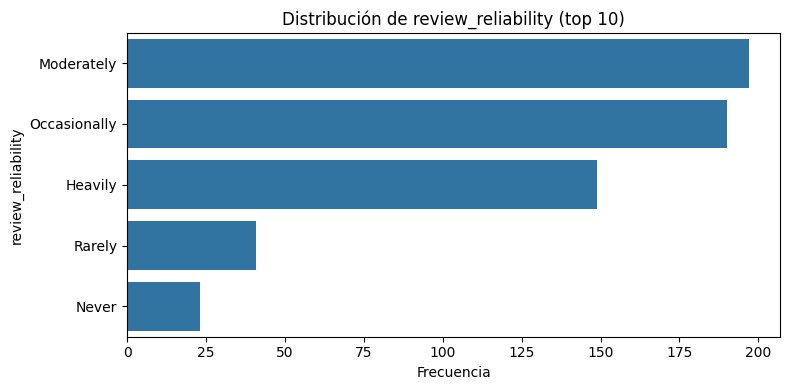


Procesando: review_helpfulness

=== review_helpfulness ===


,count,fraction
review_helpfulness,,
Yes,237,0.395
Sometimes,226,0.377
No,137,0.228


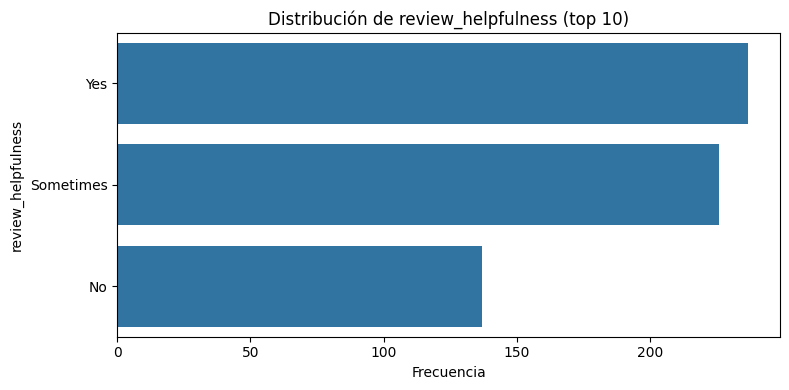


Procesando: personalized_recommendation_frequency
[ERROR] en personalized_recommendation_frequency: Grouper for 'personalized_recommendation_frequency' not 1-dimensional

Procesando: recommendation_helpfulness

=== recommendation_helpfulness ===


,count,fraction
recommendation_helpfulness,,
Sometimes,272,0.453
No,171,0.285
Yes,157,0.262


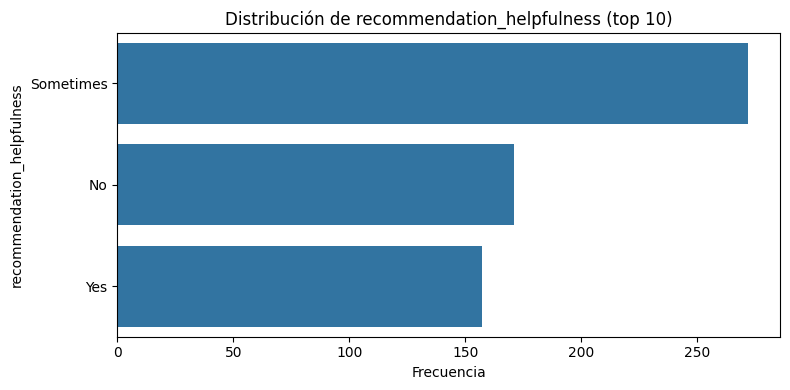


Procesando: service_appreciation

=== service_appreciation ===


,count,fraction
service_appreciation,,
Product recommendations,185,0.308
Competitive prices,182,0.303
Wide product selection,149,0.248
User-friendly website/app interface,79,0.132
.,1,0.002
Customer service,1,0.002
Customer service,1,0.002
Quick delivery,1,0.002
All the above,1,0.002


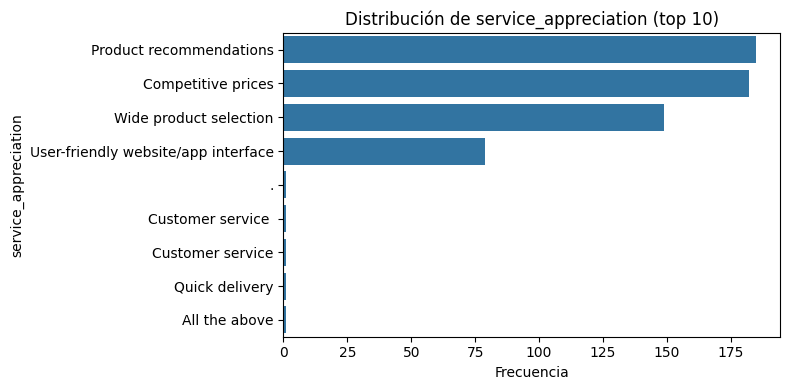


Procesando: improvement_areas

=== improvement_areas ===


,count,fraction
improvement_areas,,
Customer service responsiveness,216,0.360
Product quality and accuracy,159,0.265
Reducing packaging waste,133,0.222
Shipping speed and reliability,78,0.130
.,1,0.002
Nothing,1,0.002
better app interface and lower shipping charges,1,0.002
Nil,1,0.002
Add more familiar brands to the list,1,0.002


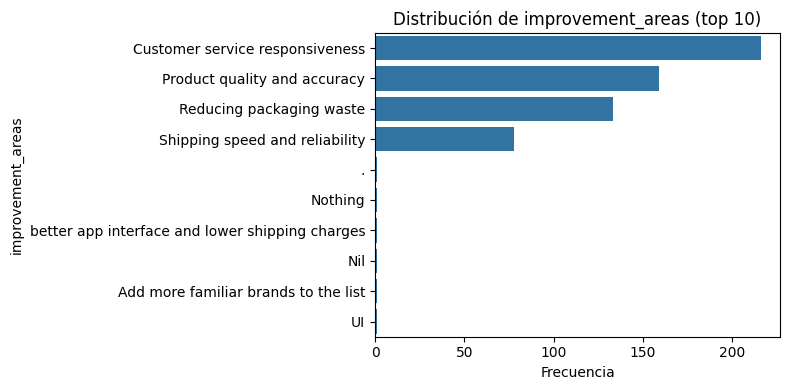


Procesando: purchase_categories_list

=== purchase_categories_list ===


,count,fraction
purchase_categories_list,,
Beauty and Personal Care,106,0.177
Clothing and Fashion,105,0.175
others,48,0.080
"Beauty and Personal Care,Clothing and Fashion",46,0.077
"Beauty and Personal Care,Clothing and Fashion,Home and Kitchen",42,0.070
"Groceries and Gourmet Food,Beauty and Personal Care,Clothing and Fashion,Home and Kitchen,others",32,0.053
"Clothing and Fashion,Home and Kitchen",27,0.045
Home and Kitchen,24,0.040
"Beauty and Personal Care,Home and Kitchen",21,0.035


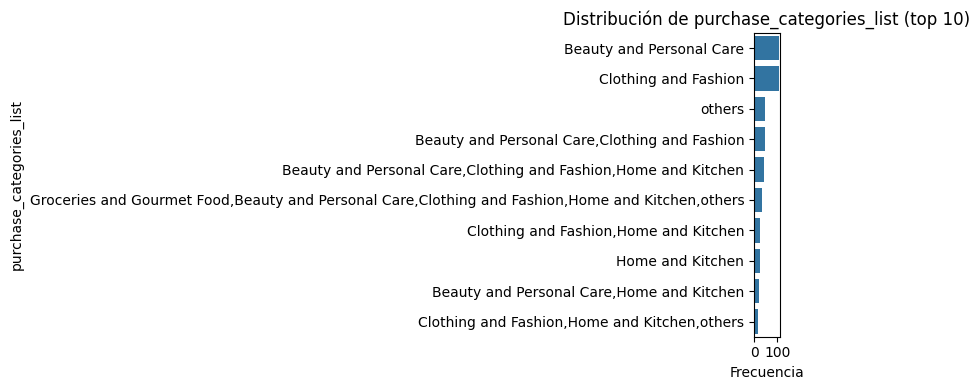

In [23]:
for col in cat_cols:
    print("\nProcesando:", col)
    try:
        categorical_univariate_report(df, col, top_n=10, plot=True)
    except Exception as e:
        print(f"[ERROR] en {col}: {e}")

## 4. Tratamiento preliminar de variables categóricas complejas

Algunas columnas contienen múltiples categorías en una misma celda, separadas por `;`
(por ejemplo, `purchase_categories`).

En esta sección:
- Se explotan estas columnas en categorías individuales.
- Se calcula la frecuencia global de cada categoría elemental.
- Se pueden crear variables binarias (flags) para categorías relevantes.

In [24]:
multi_col = "purchase_categories"

cats_series = (
    df[multi_col]
      .dropna()
      .str.split(";", expand=True)
      .stack()
      .str.strip()
)

cats_series.name = "category_item"

cats_series.value_counts().head(20)

category_item
Clothing and Fashion          341
Beauty and Personal Care      317
Home and Kitchen              219
others                        165
Groceries and Gourmet Food    111
Name: count, dtype: int64

In [25]:
# 4.2 Frecuencias relativas
cats_freq = cats_series.value_counts(normalize=True).rename("fraction")
cats_freq.head(20)

category_item
Clothing and Fashion          0.295750
Beauty and Personal Care      0.274935
Home and Kitchen              0.189939
others                        0.143105
Groceries and Gourmet Food    0.096271
Name: fraction, dtype: float64

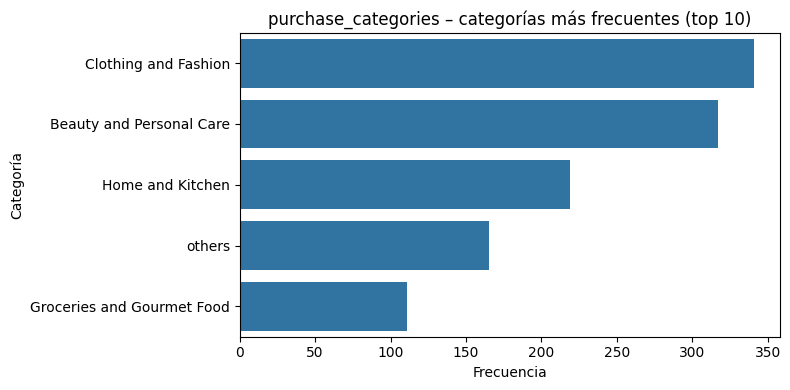

In [26]:
top_n = 10
top_labels = cats_series.value_counts().head(top_n).index.tolist()

plt.figure(figsize=(8, 4))
sns.countplot(
    y=cats_series,
    order=top_labels
)
plt.title(f"{multi_col} – categorías más frecuentes (top {top_n})")
plt.xlabel("Frecuencia")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

In [46]:
# 4.4 Creación de flags binarios para algunas categorías clave (ejemplo)
key_cats = [
    "Beauty and Personal Care",
    "Clothing and Fashion",
    "Groceries and Gourmet Food",
    "Home and Kitchen",
    "others"
]

for cat in key_cats:
    col_name = f"buys_{cat.lower().replace(' ', '_')}"
    df[col_name] = df[multi_col].str.contains(cat, na=False)
    
df[[multi_col] + [c for c in df.columns if c.startswith("buys_")]].head()

,purchase_categories,buys_beauty,buys_fashion,buys_beauty_and_personal_care,buys_clothing_and_fashion,buys_groceries_and_gourmet_food,buys_home_and_kitchen,buys_others
0,Beauty and Personal Care,True,False,True,False,False,False,False
1,Clothing and Fashion,False,True,False,True,False,False,False
2,Groceries and Gourmet Food;Clothing and Fashion,False,True,False,True,True,False,False
3,Beauty and Personal Care;Clothing and Fashion;...,True,True,True,True,False,False,True
4,Beauty and Personal Care;Clothing and Fashion,True,True,True,True,False,False,False


### Comentarios esperados

- Cuáles son las categorías de producto más frecuentes.
    - Clothing and fashion
    - Beauty and care
- Si tiene sentido crear dummies/flags para las categorías principales.
- Notas sobre la categoría `others` y si agrupa demasiados casos heterogéneos.
    - Las categorías más frecuentes son moda y cuidado personal, que juntas suman más de la mitad de las selecciones
    - La categoría others agrupa un 14 % de las selecciones, por lo que no es marginal y puede estar mezclando productos diversos; esto limita la interpretación y en un contexto real sería deseable desglosarla mejor

## 5. Resumen de hallazgos

En esta fase se ha:
- Evaluado la calidad de datos (nulos, duplicados, cardinalidad).
- Exploradas las distribuciones univariantes de variables numéricas y categóricas.
- Analizado la variable `purchase_categories` y generado variables indicadoras.

Estos resultados servirán de base para:
- Análisis bivariantes (relaciones entre satisfacción y comportamiento, entre edad y tipos de compra, etc.).
- Preparación de datos para modelado (codificación de categóricas, tratamiento de outliers, imputación de nulos).

In [30]:
# df limpio + flags
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

multi_col = "purchase_categories"

df["buys_beauty_and_personal_care"] = df[multi_col].str.contains("Beauty and Personal Care", na=False)
df["buys_clothing_and_fashion"]    = df[multi_col].str.contains("Clothing and Fashion", na=False)
df["buys_groceries_and_gourmet_food"] = df[multi_col].str.contains("Groceries and Gourmet Food", na=False)
df["buys_home_and_kitchen"]        = df[multi_col].str.contains("Home and Kitchen", na=False)
df["buys_others"]                  = df[multi_col].str.contains("others", na=False)

# Guardar dataset preparado para el EDA bivariante
df.to_csv("../data/amazon_client_behavior_prepared.csv", index=False)

* Tiene sentido usar las flags de las cuatro categorías principales (fashion, beauty, home, groceries) como variables de interés.

* Para others, yo la mantendría como flag, pero en las conclusiones remarcaría que es un grupo heterogéneo y que los patrones que veas ahí son menos accionables.

In [32]:
df1 = pd.read_csv("../data/amazon_client_behavior_prepared.csv")
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 31 columns):
 #   Column                                   Non-Null Count  Dtype
---  ------                                   --------------  -----
 0   timestamp                                600 non-null    str  
 1   age                                      600 non-null    int64
 2   gender                                   600 non-null    str  
 3   purchase_frequency                       600 non-null    str  
 4   purchase_categories                      600 non-null    str  
 5   personalized_recommendation_frequency    600 non-null    str  
 6   browsing_frequency                       600 non-null    str  
 7   product_search_method                    600 non-null    str  
 8   search_result_exploration                600 non-null    str  
 9   customer_reviews_importance              600 non-null    int64
 10  add_to_cart_browsing                     600 non-null    str  
 11  cart_completion_f